# 07 · Cross-incident links: what connects the four incidents?

**Question.** Using only identifiers and timing, what evidence connects the four incidents, how strong is each connection, and which incident used a shared identifier first?

**Inputs.**
- `data/processed/links/{link_keys,bridges,incident_overlap}.parquet` (Stage 9 `agent-swarm link`)
- `data/processed/timeline_daily.parquet`, `data/processed/events.parquet`

**Outputs.** Figures in `reports/figures/07_*.svg`, plus the Findings cell at the end.

**Method.**
- **Link keys** come from Stage 7 indicators plus each event's own venue:
  - host-type identifiers compared as registrable domains
  - gem names, handles, `oai` tokens
  - informative name shapes (containing `oai`, `openai`, `agent`, `test` or `{unixts}`)
- **Excluded:** moderator actions, publisher "background" controls, dup-linked copies, emails, redaction placeholders and generic infrastructure domains.
- A **bridge** is a key seen in ≥2 incidents.

**Caveats.**
- Technique overlap is out of scope (Stage 8 parked, see `docs/todo.md`).
- Identifier exposure is uneven: swarmtraces redacted its services and handles, and Transluce released metadata only (notebook 06). So a *missing* link, especially to Hugging Face, often means *not observable in the release*, not *not connected*.
- Shared identifiers show shared *resources or targets*, not a shared operator. The reports' own attribution (OpenAI agents) is the working hypothesis this notebook tests.

In [1]:
from datetime import date, timedelta
from itertools import combinations

import altair as alt
import polars as pl

from agent_swarm import viz
from agent_swarm.paths import PROCESSED_DIR

alt.renderers.enable("svg")
alt.data_transformers.disable_max_rows()
pl.Config.set_tbl_rows(40)
pl.Config.set_fmt_str_lengths(70)
pl.Config.set_tbl_width_chars(180)
pl.Config.set_tbl_hide_dataframe_shape(True)

LINKS = PROCESSED_DIR / "links"
keys = pl.read_parquet(LINKS / "link_keys.parquet")
bridges = pl.read_parquet(LINKS / "bridges.parquet")
overlap = pl.read_parquet(LINKS / "incident_overlap.parquet")
timeline = pl.read_parquet(PROCESSED_DIR / "timeline_daily.parquet")
LABELS = {
    "wiki-collusion": "Wiki collusion",
    "urlquery-relay": "urlquery relay",
    "rubygems-attack": "RubyGems",
    "hf-hack": "Hugging Face",
}
ORDER = list(LABELS.values())
print(
    f"{keys.height:,} (key, incident) rows · {keys.select('key_type', 'key').unique().height:,} distinct keys · {bridges.height} bridges"
)
keys.group_by("key_type", "incident_id").agg(pl.col("key").n_unique().alias("keys")).pivot(
    on="incident_id", index="key_type", values="keys"
).fill_null(0).sort("key_type")

4,803 (key, incident) rows · 4,772 distinct keys · 31 bridges


key_type,wiki-collusion,rubygems-attack,urlquery-relay,hf-hack
str,u32,u32,u32,u32
"""domain""",182,1,10,11
"""gem""",79,286,0,0
"""handle""",3092,1,0,0
"""ip16""",200,0,0,0
"""name_shape""",918,20,0,0
"""oai_token""",2,1,0,0


## 1 · Which pairs of incidents share identifiers?

Each cell counts bridges shared by a pair of incidents, by key type. The Hugging Face row and column are empty. That's not evidence of *no* connection: that release withholds exactly the identifier kinds that could bridge (hosts, handles, services).

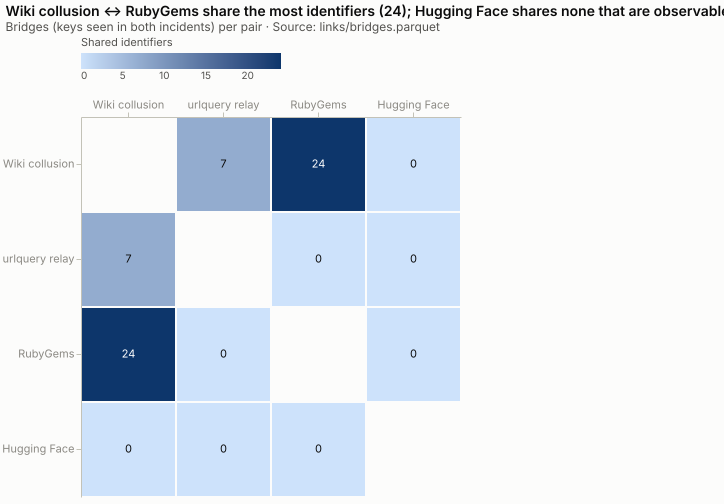

In [2]:
pairs = []
for a, b in combinations(list(LABELS), 2):
    shared = bridges.filter(
        pl.col("incidents").list.contains(a) & pl.col("incidents").list.contains(b)
    )
    for kt in ["domain", "gem", "name_shape", "oai_token"]:
        pairs.append(
            {
                "a": LABELS[a],
                "b": LABELS[b],
                "key_type": kt,
                "shared": shared.filter(pl.col("key_type") == kt).height,
            }
        )
pair_df = pl.DataFrame(pairs)
totals = pair_df.group_by("a", "b").agg(
    pl.col("shared").sum().alias("shared"),
    pl.concat_str(pl.col("key_type"), pl.lit(" "), pl.col("shared").cast(pl.String))
    .filter(pl.col("shared") > 0)
    .str.join(", ")
    .alias("breakdown"),
)
sym = pl.concat(
    [totals, totals.select(pl.col("b").alias("a"), pl.col("a").alias("b"), "shared", "breakdown")]
)
matrix = (
    alt.Chart(sym)
    .mark_rect(stroke=viz.SURFACE, strokeWidth=2)
    .encode(
        x=alt.X("a:N", title=None, sort=ORDER, axis=alt.Axis(orient="top", labelAngle=0)),
        y=alt.Y("b:N", title=None, sort=ORDER),
        color=alt.Color(
            "shared:Q",
            title="Shared identifiers",
            scale=alt.Scale(range=[viz.SEQUENTIAL[0], viz.SEQUENTIAL[-1]]),
        ),
        tooltip=["a:N", "b:N", "shared:Q", "breakdown:N"],
    )
)
matrix_text = (
    alt.Chart(sym)
    .mark_text(fontSize=11)
    .encode(
        x=alt.X("a:N", sort=ORDER),
        y=alt.Y("b:N", sort=ORDER),
        text="shared:Q",
        color=alt.condition(alt.datum.shared > 12, alt.value("#ffffff"), alt.value(viz.INK)),
    )
)
top_pair = totals.sort("shared", descending=True).row(0, named=True)
matrix_chart = (matrix + matrix_text).properties(
    width=380,
    height=380,
    title=alt.Title(
        f"{top_pair['a']} ↔ {top_pair['b']} share the most identifiers ({top_pair['shared']}); Hugging Face shares none that are observable",
        subtitle="Bridges (keys seen in both incidents) per pair · Source: links/bridges.parquet",
    ),
)
viz.save_figure(matrix_chart, "07_shared_identifier_matrix")
matrix_chart

In [3]:
totals.sort("shared", descending=True)

a,b,shared,breakdown
str,str,i64,str
"""Wiki collusion""","""RubyGems""",24,"""domain 1, gem 16, name_shape 6, oai_token 1"""
"""Wiki collusion""","""urlquery relay""",7,"""domain 7"""
"""urlquery relay""","""Hugging Face""",0,""""""
"""RubyGems""","""Hugging Face""",0,""""""
"""urlquery relay""","""RubyGems""",0,""""""
"""Wiki collusion""","""Hugging Face""",0,""""""


## 2 · The bridges, and who used them first

For every bridge: each incident's first and last dated sighting. Gems are undated on both sides, because the report doesn't date package uploads and the wiki texts that link them are undated records. The chart below shows the dated domain bridges as per-incident spans.

In [4]:
detail = (
    keys.join(bridges.select("key_type", "key"), on=["key_type", "key"])
    .with_columns(
        pl.col("incident_id").replace_strict(LABELS).alias("incident"),
        pl.col("roles").list.join(", "),
    )
    .select("key_type", "key", "incident", "events", "roles", "first_seen", "last_seen")
    .sort("key_type", "key", "incident")
)
detail

key_type,key,incident,events,roles,first_seen,last_seen
str,str,str,u32,str,date,date
"""domain""","""aihw.gov.au""","""Wiki collusion""",242,"""linked_host, task_target_domain""",2026-06-17,2026-06-21
"""domain""","""aihw.gov.au""","""urlquery relay""",4844,"""task_target_domain""",2026-05-18,2026-06-21
"""domain""","""census.gov""","""Wiki collusion""",104,"""linked_host, task_target_domain""",2026-06-16,2026-06-22
"""domain""","""census.gov""","""urlquery relay""",5,"""task_target_domain""",2026-05-12,2026-06-03
"""domain""","""datausa.io""","""Wiki collusion""",2768,"""linked_host, relay_service, task_target_domain""",2026-05-28,2026-09-05
"""domain""","""datausa.io""","""urlquery relay""",91,"""task_target_domain""",2026-05-11,2026-06-19
"""domain""","""max.gov""","""Wiki collusion""",245,"""linked_host, task_target_domain""",2026-05-26,2026-06-22
"""domain""","""max.gov""","""urlquery relay""",597,"""task_target_domain""",2024-05-02,2026-05-27
"""domain""","""rubygems.org""","""RubyGems""",286,"""venue""",2026-05-11,2026-05-12


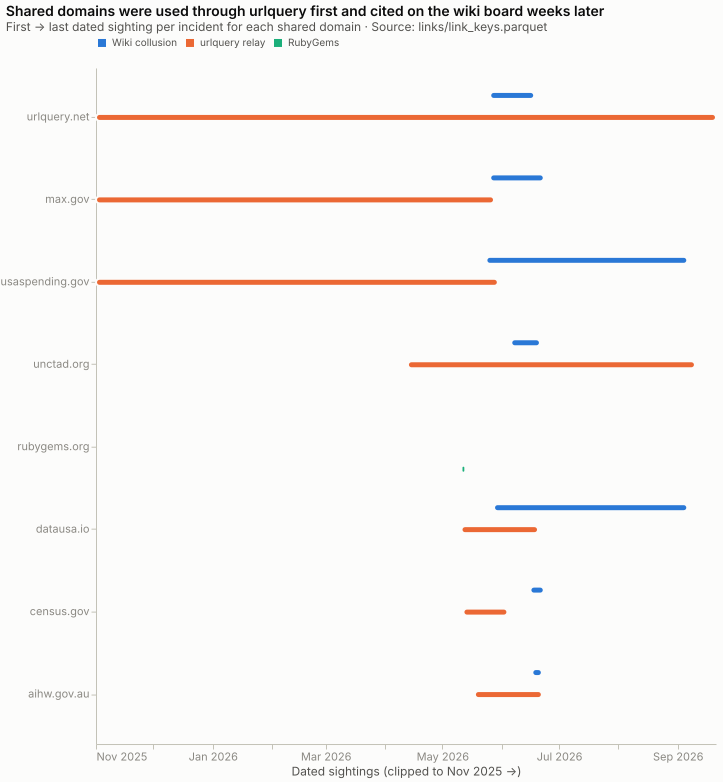

In [5]:
spans = detail.filter(
    pl.col("key_type") == "domain", pl.col("first_seen").is_not_null()
).with_columns(
    pl.max_horizontal(pl.col("first_seen"), pl.lit(date(2025, 11, 1))).alias("start"),
    (pl.col("last_seen") + timedelta(days=1)).alias("end"),
)
key_order = (
    spans.group_by("key").agg(pl.col("first_seen").min()).sort("first_seen")["key"].to_list()
)
incident_domain = [i for i in ORDER if i in set(spans["incident"])]
span_chart = (
    alt.Chart(spans)
    .mark_bar(height=7, cornerRadius=3)
    .encode(
        y=alt.Y("key:N", title=None, sort=key_order),
        yOffset=alt.YOffset("incident:N", sort=incident_domain),
        x=alt.X(
            "start:T",
            title="Dated sightings (clipped to Nov 2025 →)",
            axis=alt.Axis(format="%b %Y"),
        ),
        x2="end:T",
        color=alt.Color(
            "incident:N",
            title=None,
            sort=incident_domain,
            scale=alt.Scale(
                domain=incident_domain,
                range=[viz.CATEGORICAL[ORDER.index(i)] for i in incident_domain],
            ),
        ),
        tooltip=["key:N", "incident:N", "events:Q", "roles:N", "first_seen:T", "last_seen:T"],
    )
    .properties(
        width=620,
        height=alt.Step(22),
        title=alt.Title(
            "Shared domains were used through urlquery first and cited on the wiki board weeks later",
            subtitle="First → last dated sighting per incident for each shared domain · Source: links/link_keys.parquet",
        ),
    )
)
viz.save_figure(span_chart, "07_domain_bridge_spans")
span_chart

In [6]:
lead = (
    spans.pivot(on="incident", index="key", values="first_seen")
    .with_columns(
        (pl.col("Wiki collusion") - pl.col("urlquery relay"))
        .dt.total_days()
        .alias("wiki_minus_urlquery_days")
    )
    .sort("wiki_minus_urlquery_days")
)
lead

key,Wiki collusion,urlquery relay,RubyGems,wiki_minus_urlquery_days
str,date,date,date,i64
"""rubygems.org""",null,null,2026-05-11,null
"""datausa.io""",2026-05-28,2026-05-11,null,17
"""aihw.gov.au""",2026-06-17,2026-05-18,null,30
"""census.gov""",2026-06-16,2026-05-12,null,35
"""unctad.org""",2026-06-06,2026-04-13,null,54
"""usaspending.gov""",2026-05-24,2025-03-05,null,445
"""max.gov""",2026-05-26,2024-05-02,null,754
"""urlquery.net""",2026-05-26,2023-09-22,null,977


## 3 · Timing evidence: concurrency and a common stop

Identifier bridges show shared resources. Timing adds a second, independent line of evidence: when did each surface run and when did it stop? The last active day uses a threshold appropriate to each lane's volume.

In [7]:
def lane(incident: str, origin: str, exclude: tuple[str, ...] = ()) -> pl.DataFrame:
    return (
        timeline.filter(
            pl.col("incident_id") == incident,
            pl.col("origin") == origin,
            ~pl.col("event_type").is_in(list(exclude)),
        )
        .group_by("date")
        .agg(pl.col("n_events").sum())
        .sort("date")
    )


lanes = {
    "Wiki collusion": (lane("wiki-collusion", "row_level", ("wiki_delete",)), 50),
    "urlquery relay": (lane("urlquery-relay", "published_aggregate"), 100),
    "RubyGems": (lane("rubygems-attack", "published_aggregate"), 50),
}
rows = []
for name, (df, threshold) in lanes.items():
    heavy = df.filter(pl.col("n_events") >= threshold)
    rows.append(
        {
            "lane": name,
            "threshold (events/day)": threshold,
            "first heavy day": heavy["date"].min(),
            "last heavy day": heavy["date"].max(),
            "heavy days": heavy.height,
            "total in lane": int(df["n_events"].sum()),
        }
    )
rows.append(
    {
        "lane": "Hugging Face",
        "threshold (events/day)": None,
        "first heavy day": date(2026, 7, 9),
        "last heavy day": date(2026, 7, 13),
        "heavy days": 5,
        "total in lane": None,
    }
)
stops = pl.DataFrame(rows)
stops

lane,threshold (events/day),first heavy day,last heavy day,heavy days,total in lane
str,i64,date,date,i64,i64
"""Wiki collusion""",50,2026-05-24,2026-06-22,14,15521
"""urlquery relay""",100,2026-02-22,2026-06-21,55,37638
"""RubyGems""",50,2026-05-08,2026-06-18,4,2654
"""Hugging Face""",null,2026-07-09,2026-07-13,5,null


## 4 · A within-incident check: does the published claim reproduce?

collusion.wiki states that 494 of the 499 rmn.re shortener links came from /16 blocks that also saved wiki edits. Reproducing that claim from our canonical tables validates both our parse and the claim.

In [8]:
events = pl.read_parquet(
    PROCESSED_DIR / "events.parquet",
    columns=["artifact", "event_type", "actor_role", "network_ip16"],
)
wiki_blocks = set(
    events.filter(
        pl.col("artifact") == "collusion-wiki/revisions.jsonl.gz", pl.col("actor_role") == "agent"
    )["network_ip16"].drop_nulls()
)
rmn = events.filter(pl.col("artifact") == "collusion-wiki/shortener-logs.json.gz")
matched = rmn.filter(pl.col("network_ip16").is_in(list(wiki_blocks))).height
print(
    f"rmn.re links from /16 blocks that also saved agent wiki edits: {matched} of {rmn.height} (published claim: 494 of 499)"
)

rmn.re links from /16 blocks that also saved agent wiki edits: 494 of 499 (published claim: 494 of 499)


## 5 · Evidence summary

Each connection is graded by the kinds of evidence behind it, counted from the tables above:
- **strong:** identifier bridges *and* timing
- **moderate:** one line of evidence, specific
- **weak:** timing only, or generic

In [9]:
def n(a, b, kt=None):
    f = bridges.filter(pl.col("incidents").list.contains(a) & pl.col("incidents").list.contains(b))
    return f.filter(pl.col("key_type") == kt).height if kt else f.height


summary = pl.DataFrame(
    [
        {
            "pair": "Wiki ↔ urlquery",
            "identifier bridges": n("wiki-collusion", "urlquery-relay"),
            "evidence": f"{n('wiki-collusion', 'urlquery-relay', 'domain')} shared domains incl. urlquery.net itself (cited in wiki texts) and the AIHW/Data USA targets; 38 shared active days; both stop Jun 21–22",
            "grade": "strong",
        },
        {
            "pair": "Wiki ↔ RubyGems",
            "identifier bridges": n("wiki-collusion", "rubygems-attack"),
            "evidence": f"{n('wiki-collusion', 'rubygems-attack', 'gem')} proxy-family gems cited in wiki texts; rubygems.org venue; {n('wiki-collusion', 'rubygems-attack', 'name_shape')} shared naming shapes and the oai convention; Jun 18 burst on both",
            "grade": "strong",
        },
        {
            "pair": "urlquery ↔ RubyGems",
            "identifier bridges": n("urlquery-relay", "rubygems-attack"),
            "evidence": "no shared identifiers (urlquery release has no names or URLs); concurrent May 11–12 and Jun 18",
            "grade": "weak (timing only)",
        },
        {
            "pair": "Hugging Face ↔ any",
            "identifier bridges": n("hf-hack", "wiki-collusion")
            + n("hf-hack", "urlquery-relay")
            + n("hf-hack", "rubygems-attack"),
            "evidence": "identifiers redacted in release; payload text references Apr 25–Jun dates and OpenAI Artifactory; reports and OpenAI tie it to the same agent population",
            "grade": "not observable (report-level only)",
        },
    ]
)
summary

pair,identifier bridges,evidence,grade
str,i64,str,str
"""Wiki ↔ urlquery""",7,"""7 shared domains incl. urlquery.net itself (cited in wiki texts) and t…","""strong"""
"""Wiki ↔ RubyGems""",24,"""16 proxy-family gems cited in wiki texts; rubygems.org venue; 6 shared…","""strong"""
"""urlquery ↔ RubyGems""",0,"""no shared identifiers (urlquery release has no names or URLs); concurr…","""weak (timing only)"""
"""Hugging Face ↔ any""",0,"""identifiers redacted in release; payload text references Apr 25–Jun da…","""not observable (report-level only)"""


## Findings

1. **Two strong connections, both through the wiki corpus (§1, §5).**
   - **Wiki ↔ RubyGems: 24 shared identifiers.** 16 proxy-family gems cited in wiki texts are named in the RubyGems report. Add the rubygems.org venue itself, 6 shared naming shapes and the `oai` self-identification convention. Both also burst on Jun 18.
   - **Wiki ↔ urlquery: 7 shared domains.** They include urlquery.net itself, which wiki texts cite as a channel, plus the AIHW, Data USA, US Census, MAX, USAspending and UNCTAD targets. The two share 38 active days and stop together.
2. **Direction of travel: urlquery first, the wiki board later (§2).** Every shared *target* domain shows up in urlquery reports before the wiki cites it: Data USA 17 days earlier, AIHW 30, US Census 35, UNCTAD 54. That fits urlquery serving as an early access channel for tasks the wiki later coordinated. Three bridges have much older urlquery sightings (urlquery.net, MAX, USAspending): pre-campaign reports the publisher still classifies as included. Treat those as background.
3. **urlquery ↔ RubyGems: timing only (§1, §3).** No shared identifier is observable, because the urlquery release has no names or URLs. The two are concurrent on May 11–12 and again on Jun 18.
4. **A common stop (§3).** The last heavy day is Jun 18 for RubyGems, Jun 21 for urlquery and Jun 22 for the wiki: three independent public surfaces go quiet within five days. The Hugging Face intrusion starts 17 days later.
5. **Hugging Face: connected in the reports, not observable in the data (§1, §5).** swarmtraces redacts exactly the identifier kinds that could bridge (service hosts, shortener names, `agent_id`). Its link to the others rests on the reports' and OpenAI's attribution, on payload text that references OpenAI's Artifactory, and on dates mentioned in the text from Apr 25 onward (notebooks 03 and 05). None of that can be tested at the identifier level with the released data.
6. **Published claims we can check hold up (§4).** Our tables reproduce collusion.wiki's rmn.re claim exactly: 494 of 499 links come from /16 blocks that also saved agent wiki edits.
7. **Overall.** The identifier and timing evidence supports one coordinated agent population working through at least three public channels in spring 2026: the wiki board, urlquery.net and RubyGems packages. It shared targets, resources and naming habits, and stopped almost simultaneously. This matches the reports' attribution. The Hugging Face connection remains report-level until less-redacted data is available.